# Arya Phones — Round-by-Round Customer Simulation

MNL demand computed **per segment per round**. Tracks how supplier selection, price, and delta changes affect each customer group over time.

## Scenarios
1. **Price War** — 3 teams, same set [P], price competition over 6 rounds
2. **Selection Shock** — TeamA upgrades from [P] to [P,O,N] in round 4
3. **Delta Sweep** — same teams/prices, delta rises 0.02→0.5 each round
4. **Tournament** — 4 teams, 8 rounds, Beta distribution shifts at round 5

In [1]:
import sys, warnings
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

PROJECT_ROOT = Path('../..').resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

warnings.filterwarnings('ignore')

from server.app.service import get_tables
from server.app.settings import GAME_SETTINGS
from server.app.beta_density import BetaDensity
from server.app.mnl_market import BuyerProfile, run_mnl_market
from server.app.customer_segment import CustomerSegment

suppliers_df, users_df = get_tables()
N = len(users_df)
print(f'Suppliers: {len(suppliers_df)}  |  Segments: {N}')
PALETTE = ['#2563eb','#dc2626','#059669','#7c3aed','#d97706','#0891b2','#be123c','#65a30d']


Suppliers: 18  |  Segments: 20


In [2]:
# ─── Helpers ─────────────────────────────────────────────────────────────

def avg_attrs(picks):
    sel = suppliers_df[suppliers_df['supplier_id'].isin(picks)]
    if sel.empty: return {}
    return {c: float(sel[c].mean()) for c in
            ['env_risk','social_risk','cost_score','strategic','improvement','low_quality']}

def is_feasible(picks):
    a = avg_attrs(picks)
    return (len(picks) > 0
            and a.get('env_risk', 99) <= GAME_SETTINGS.env_cap + 1e-9
            and a.get('social_risk', 99) <= GAME_SETTINGS.social_cap + 1e-9)

def make_segments(alpha=3.0, beta=3.0):
    bd = BetaDensity(alpha=max(0.01, alpha), beta=max(0.01, beta))
    us = users_df.sort_values('w_cost').reset_index(drop=True)
    return [
        CustomerSegment(
            segment_id=str(row['user_id']),
            density=float(bd.density_at((i + 0.5) / N)),
            w_env=float(row.get('w_env', 0)),
            w_social=float(row.get('w_social', 0)),
            w_cost=float(row.get('w_cost', 1)),
            w_strategic=float(row.get('w_strategic', 0)),
            w_improvement=float(row.get('w_improvement', 0)),
            w_low_quality=float(row.get('w_low_quality', 0)),
        )
        for i, (_, row) in enumerate(us.iterrows())
    ]

def buyer_profile(name, picks, price):
    a = avg_attrs(picks)
    return BuyerProfile(
        team_name=name, price_per_user=float(price),
        avg_env=a.get('env_risk', 0), avg_social=a.get('social_risk', 0),
        avg_strategic=a.get('strategic', 0), avg_improvement=a.get('improvement', 0),
        avg_low_quality=a.get('low_quality', 0),
    )

def run_round(team_specs, alpha=3.0, beta=3.0, delta=0.1, u_outside=-3.0):
    """Returns (round_df, segment_df). One row per team / per (team x segment)."""
    segs = make_segments(alpha, beta)
    profiles = [buyer_profile(name, picks, price) for name, picks, price in team_specs]
    result = run_mnl_market(profiles, segs, delta=delta, u_outside=u_outside)

    us_s = users_df.sort_values('w_cost').reset_index(drop=True)
    seg_idx  = {str(r['user_id']): i+1    for i,(_, r) in enumerate(us_s.iterrows())}
    seg_wc   = {str(r['user_id']): float(r['w_cost']) for _, r in us_s.iterrows()}
    total_d  = sum(s.density for s in segs)

    team_rows = []
    for name, picks, price in team_specs:
        a  = avg_attrs(picks)
        br = result.buyer_results.get(name)
        demand = br.total_demand if br else 0.0
        eff    = demand * N
        margin = price - GAME_SETTINGS.cost_scale * a.get('cost_score', 0)
        team_rows.append({
            'team': name, 'picks': ','.join(picks), 'feasible': is_feasible(picks),
            'price': price, 'delta': delta, 'alpha': alpha, 'beta': beta,
            'demand_share_pct':  round(demand * 100, 2),
            'effective_users':   round(eff, 3),
            'unit_margin':       round(margin, 2),
            'realized_profit':   round(eff * margin, 2),
            'realized_utility':  round((br.realized_utility * N) if br else 0.0, 3),
            'avg_env':   round(a.get('env_risk', 0), 3),
            'avg_social':round(a.get('social_risk', 0), 3),
            'avg_cost':  round(a.get('cost_score', 0), 3),
        })

    seg_rows = []
    for alloc in result.segment_allocations:
        sid   = alloc.segment_id
        norm  = alloc.density / total_d
        for name, picks, price in team_specs:
            a      = avg_attrs(picks)
            share  = alloc.shares.get(name, 0.0)
            eff_s  = share * norm * N
            margin = price - GAME_SETTINGS.cost_scale * a.get('cost_score', 0)
            seg_rows.append({
                'team': name,
                'segment_index': seg_idx.get(sid),
                'segment_id': sid,
                'w_cost': round(seg_wc.get(sid, 0), 4),
                'density': round(alloc.density, 4),
                'norm_density': round(norm, 4),
                'mnl_share_pct': round(share * 100, 2),
                'effective_users_seg': round(eff_s, 4),
                'unit_margin': round(margin, 2),
                'profit_seg': round(eff_s * margin, 4),
                'picks': ','.join(picks), 'price': price, 'delta': delta,
            })

    return pd.DataFrame(team_rows), pd.DataFrame(seg_rows)

def run_scenario(name, rounds_spec, delta_schedule=None):
    all_r, all_s = [], []
    for i, rnd in enumerate(rounds_spec):
        rno = rnd['round_no']
        specs = [(t['name'], t['picks'], t['price']) for t in rnd['teams']]
        av = rnd.get('alpha', 3.0); bv = rnd.get('beta', 3.0)
        if delta_schedule is None:
            d = rnd.get('delta', 0.1)
        elif isinstance(delta_schedule, (int, float)):
            d = float(delta_schedule)
        else:
            d = float(delta_schedule[i]) if i < len(delta_schedule) else float(delta_schedule[-1])
        rdf, sdf = run_round(specs, alpha=av, beta=bv, delta=d)
        rdf['round_no'] = rno; rdf['scenario'] = name
        sdf['round_no'] = rno; sdf['scenario'] = name
        all_r.append(rdf); all_s.append(sdf)
    rdf_all = pd.concat(all_r, ignore_index=True)
    rdf_all['cum_profit']  = rdf_all.groupby('team')['realized_profit'].cumsum()
    rdf_all['cum_utility'] = rdf_all.groupby('team')['realized_utility'].cumsum()
    return rdf_all, pd.concat(all_s, ignore_index=True)

print('Helpers ready.')


Helpers ready.


## Scenario 1 — Price War (same set [P], 6 rounds)
All 3 teams start at price=100. B cuts to 85 in R3, A counters to 90 in R4, C goes premium.

In [3]:
S1 = [
    {'round_no':1,'teams':[{'name':'TeamA','picks':['P'],'price':100},{'name':'TeamB','picks':['P'],'price':100},{'name':'TeamC','picks':['P'],'price':100}]},
    {'round_no':2,'teams':[{'name':'TeamA','picks':['P'],'price':100},{'name':'TeamB','picks':['P'],'price':100},{'name':'TeamC','picks':['P'],'price':100}]},
    {'round_no':3,'teams':[{'name':'TeamA','picks':['P'],'price':100},{'name':'TeamB','picks':['P'],'price':85}, {'name':'TeamC','picks':['P'],'price':100}]},
    {'round_no':4,'teams':[{'name':'TeamA','picks':['P'],'price':90}, {'name':'TeamB','picks':['P'],'price':85}, {'name':'TeamC','picks':['P'],'price':100}]},
    {'round_no':5,'teams':[{'name':'TeamA','picks':['P'],'price':90}, {'name':'TeamB','picks':['P'],'price':85}, {'name':'TeamC','picks':['P'],'price':108}]},
    {'round_no':6,'teams':[{'name':'TeamA','picks':['P'],'price':90}, {'name':'TeamB','picks':['P'],'price':80}, {'name':'TeamC','picks':['P'],'price':108}]},
]
s1_r, s1_s = run_scenario('S1_PriceWar', S1)
print(f'S1: {len(s1_r)} round rows, {len(s1_s)} segment rows')
s1_r[['round_no','team','price','demand_share_pct','realized_profit','cum_profit']]


S1: 18 round rows, 360 segment rows


,round_no,team,price,demand_share_pct,realized_profit,cum_profit
0,1,TeamA,100,29.46,522.50,522.50
1,1,TeamB,100,29.46,522.50,522.50
2,1,TeamC,100,29.46,522.50,522.50
3,2,TeamA,100,29.46,522.50,1045.00
4,2,TeamB,100,29.46,522.50,1045.00
5,2,TeamC,100,29.46,522.50,1045.00
6,3,TeamA,100,24.26,430.19,1475.19
7,3,TeamB,85,42.39,624.56,1669.56
8,3,TeamC,100,24.26,430.19,1475.19
9,4,TeamA,90,31.68,498.45,1973.64


## Scenario 2 — Selection Shock (8 rounds)
TeamA starts [P], upgrades to [P,O,N] in R4. TeamB holds [P,N,I] throughout. TeamC copies A in R6.

In [4]:
S2 = [
    {'round_no':1,'teams':[{'name':'TeamA','picks':['P'],         'price':100},{'name':'TeamB','picks':['P','N','I'],'price':95},{'name':'TeamC','picks':['P','O'],       'price':105}]},
    {'round_no':2,'teams':[{'name':'TeamA','picks':['P'],         'price':100},{'name':'TeamB','picks':['P','N','I'],'price':95},{'name':'TeamC','picks':['P','O'],       'price':100}]},
    {'round_no':3,'teams':[{'name':'TeamA','picks':['P'],         'price':100},{'name':'TeamB','picks':['P','N','I'],'price':90},{'name':'TeamC','picks':['P','O'],       'price':100}]},
    {'round_no':4,'teams':[{'name':'TeamA','picks':['P','O','N'], 'price':100},{'name':'TeamB','picks':['P','N','I'],'price':90},{'name':'TeamC','picks':['P','O'],       'price':100}]},
    {'round_no':5,'teams':[{'name':'TeamA','picks':['P','O','N'], 'price':95}, {'name':'TeamB','picks':['P','N','I'],'price':90},{'name':'TeamC','picks':['P','O'],       'price':95}]},
    {'round_no':6,'teams':[{'name':'TeamA','picks':['P','O','N'], 'price':95}, {'name':'TeamB','picks':['P','N','I'],'price':85},{'name':'TeamC','picks':['P','O','N'],   'price':95}]},
    {'round_no':7,'teams':[{'name':'TeamA','picks':['P','O','N'], 'price':90}, {'name':'TeamB','picks':['P','N','I'],'price':85},{'name':'TeamC','picks':['P','O','N'],   'price':90}]},
    {'round_no':8,'teams':[{'name':'TeamA','picks':['P','O','N'], 'price':90}, {'name':'TeamB','picks':['P','N','I'],'price':85},{'name':'TeamC','picks':['P','O','N'],   'price':85}]},
]
s2_r, s2_s = run_scenario('S2_SelectionShock', S2)
print(f'S2: {len(s2_r)} round rows')
s2_r[['round_no','team','picks','price','demand_share_pct','realized_profit','cum_profit']]


S2: 24 round rows


,round_no,team,picks,price,demand_share_pct,realized_profit,cum_profit
0,1,TeamA,P,100,31.63,560.91,560.91
1,1,TeamB,"P,N,I",95,33.55,431.80,431.80
2,1,TeamC,"P,O",105,22.69,401.98,401.98
3,2,TeamA,P,100,30.30,537.40,1098.31
4,2,TeamB,"P,N,I",95,32.11,413.27,845.07
5,2,TeamC,"P,O",100,26.04,435.29,837.27
6,3,TeamA,P,100,28.49,505.19,1603.50
7,3,TeamB,"P,N,I",90,36.37,431.64,1276.71
8,3,TeamC,"P,O",100,24.47,409.06,1246.33
9,4,TeamA,"P,O,N",100,24.11,349.11,1952.61


## Scenario 3 — Delta Sweep (6 rounds)
Same teams and prices every round; **delta rises** each round: 0.02 → 0.05 → 0.10 → 0.20 → 0.35 → 0.50.

In [5]:
DELTA_SCHED = [0.02, 0.05, 0.10, 0.20, 0.35, 0.50]
S3 = [
    {'round_no': i+1, 'teams': [
        {'name': 'TeamA [P]@100',    'picks': ['P'],         'price': 100},
        {'name': 'TeamB [P,O,N]@95', 'picks': ['P','O','N'], 'price':  95},
        {'name': 'TeamC [P,N,I]@90', 'picks': ['P','N','I'], 'price':  90},
    ]} for i in range(6)
]
s3_r, s3_s = run_scenario('S3_DeltaSweep', S3, delta_schedule=DELTA_SCHED)
print(f'S3: {len(s3_r)} round rows')
s3_r[['round_no','team','price','delta','demand_share_pct','realized_profit']]


S3: 18 round rows


,round_no,team,price,delta,demand_share_pct,realized_profit
0,1,TeamA [P]@100,100,0.02,35.80,634.85
1,1,"TeamB [P,O,N]@95",95,0.02,29.71,400.37
2,1,"TeamC [P,N,I]@90",90,0.02,34.07,404.43
3,2,TeamA [P]@100,100,0.05,33.51,594.25
4,2,"TeamB [P,O,N]@95",95,0.05,29.39,396.17
5,2,"TeamC [P,N,I]@90",90,0.05,35.71,423.91
6,3,TeamA [P]@100,100,0.10,27.82,493.31
7,3,"TeamB [P,O,N]@95",95,0.10,26.56,357.92
8,3,"TeamC [P,N,I]@90",90,0.10,35.37,419.79
9,4,TeamA [P]@100,100,0.20,10.74,190.51


## Scenario 4 — Full Tournament (4 teams, 8 rounds)
Rounds 1-4: Beta(3,3) symmetric. Rounds 5-8: Beta(1.5,5) quality-preferring — env/social quality matters more, hitting [P,O,N] and [P,N,I] differently.

In [6]:
def make_s4_round(rno, prices):
    teams_base = [
        ('Alpha [P]',     ['P']),
        ('Beta [P,O]',    ['P','O']),
        ('Gamma [P,O,N]', ['P','O','N']),
        ('Delta [P,N,I]', ['P','N','I']),
    ]
    return {
        'round_no': rno,
        'alpha': 3.0 if rno <= 4 else 1.5,
        'beta':  3.0 if rno <= 4 else 5.0,
        'teams': [{'name':n,'picks':p,'price':pr} for (n,p),pr in zip(teams_base,prices)]
    }

S4 = [
    make_s4_round(1, [110,100, 95, 90]),
    make_s4_round(2, [105,100, 95, 88]),
    make_s4_round(3, [100,100, 95, 85]),
    make_s4_round(4, [ 95, 98, 90, 85]),
    make_s4_round(5, [ 95, 98, 90, 85]),
    make_s4_round(6, [ 95, 95, 88, 82]),
    make_s4_round(7, [ 92, 95, 88, 80]),
    make_s4_round(8, [ 90, 92, 85, 80]),
]

def run_s4():
    all_r, all_s = [], []
    for rnd in S4:
        rno = rnd['round_no']
        specs = [(t['name'],t['picks'],t['price']) for t in rnd['teams']]
        rdf, sdf = run_round(specs, alpha=rnd['alpha'], beta=rnd['beta'], delta=0.1)
        rdf['round_no'] = rno; rdf['scenario'] = 'S4_Tournament'
        rdf['beta_label'] = 'Bell(3,3)' if rno <= 4 else 'QualPref(1.5,5)'
        sdf['round_no'] = rno; sdf['scenario'] = 'S4_Tournament'
        all_r.append(rdf); all_s.append(sdf)
    rdf_all = pd.concat(all_r, ignore_index=True)
    rdf_all['cum_profit']  = rdf_all.groupby('team')['realized_profit'].cumsum()
    rdf_all['cum_utility'] = rdf_all.groupby('team')['realized_utility'].cumsum()
    return rdf_all, pd.concat(all_s, ignore_index=True)

s4_r, s4_s = run_s4()
print(f'S4: {len(s4_r)} round rows')
s4_r[['round_no','team','picks','price','demand_share_pct','realized_profit','cum_profit','beta_label']]


S4: 32 round rows


,round_no,team,picks,price,demand_share_pct,realized_profit,cum_profit,beta_label
0,1,Alpha [P],P,110,16.77,331.01,331.01,"Bell(3,3)"
1,1,"Beta [P,O]","P,O",100,20.53,343.20,343.20,"Bell(3,3)"
2,1,"Gamma [P,O,N]","P,O,N",95,22.92,308.86,308.86,"Bell(3,3)"
3,1,"Delta [P,N,I]","P,N,I",90,30.61,363.28,363.28,"Bell(3,3)"
4,2,Alpha [P],P,105,18.97,355.39,686.40,"Bell(3,3)"
5,2,"Beta [P,O]","P,O",100,19.46,325.30,668.50,"Bell(3,3)"
6,2,"Gamma [P,O,N]","P,O,N",95,21.70,292.42,601.28,"Bell(3,3)"
7,2,"Delta [P,N,I]","P,N,I",88,31.26,358.57,721.85,"Bell(3,3)"
8,3,Alpha [P],P,100,21.16,375.19,1061.59,"Bell(3,3)"
9,3,"Beta [P,O]","P,O",100,18.14,303.30,971.80,"Bell(3,3)"


## Visualizations
### Time-Series: Profit / Cumulative / Share / Price

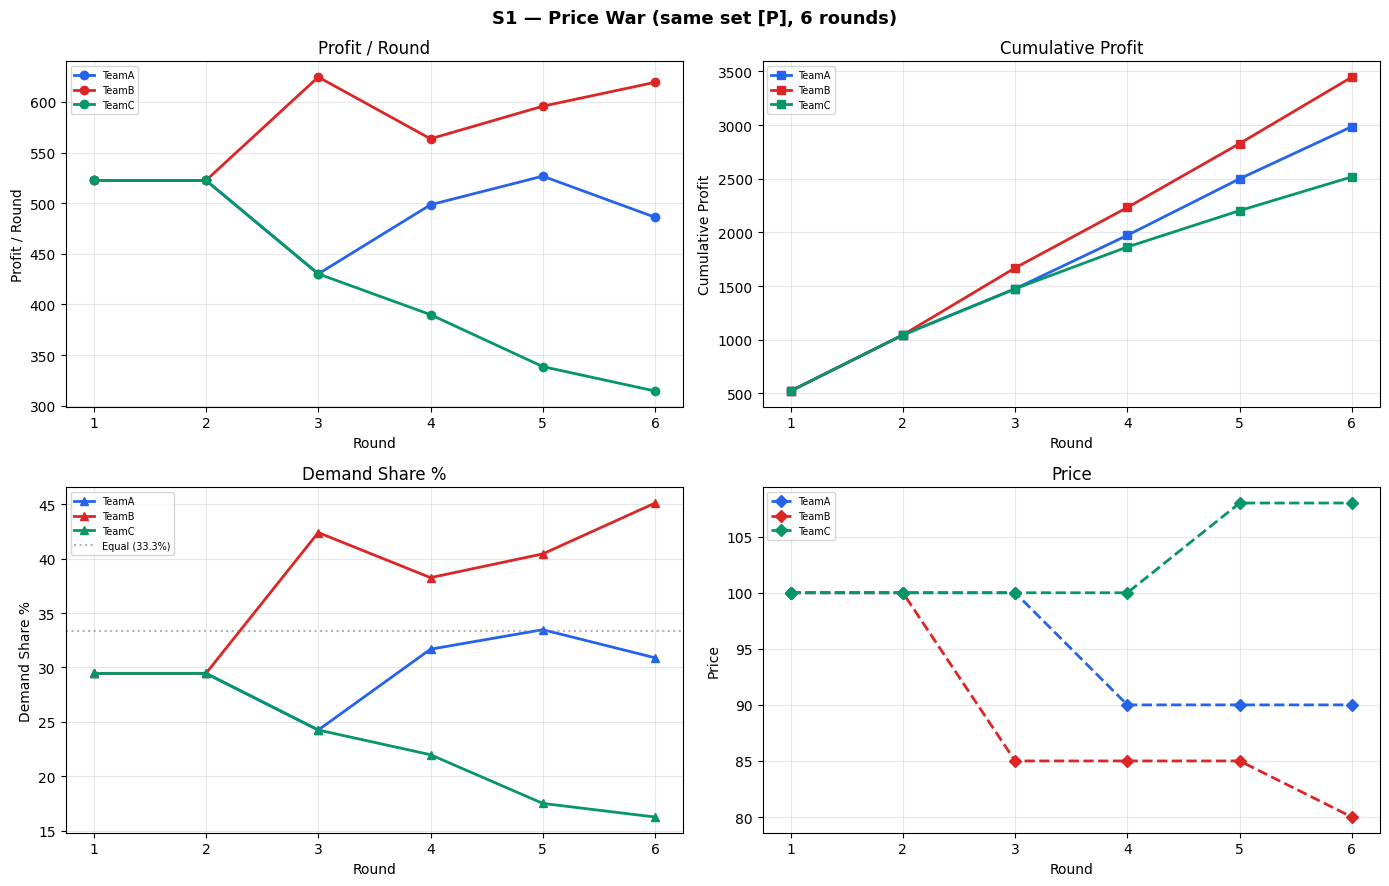

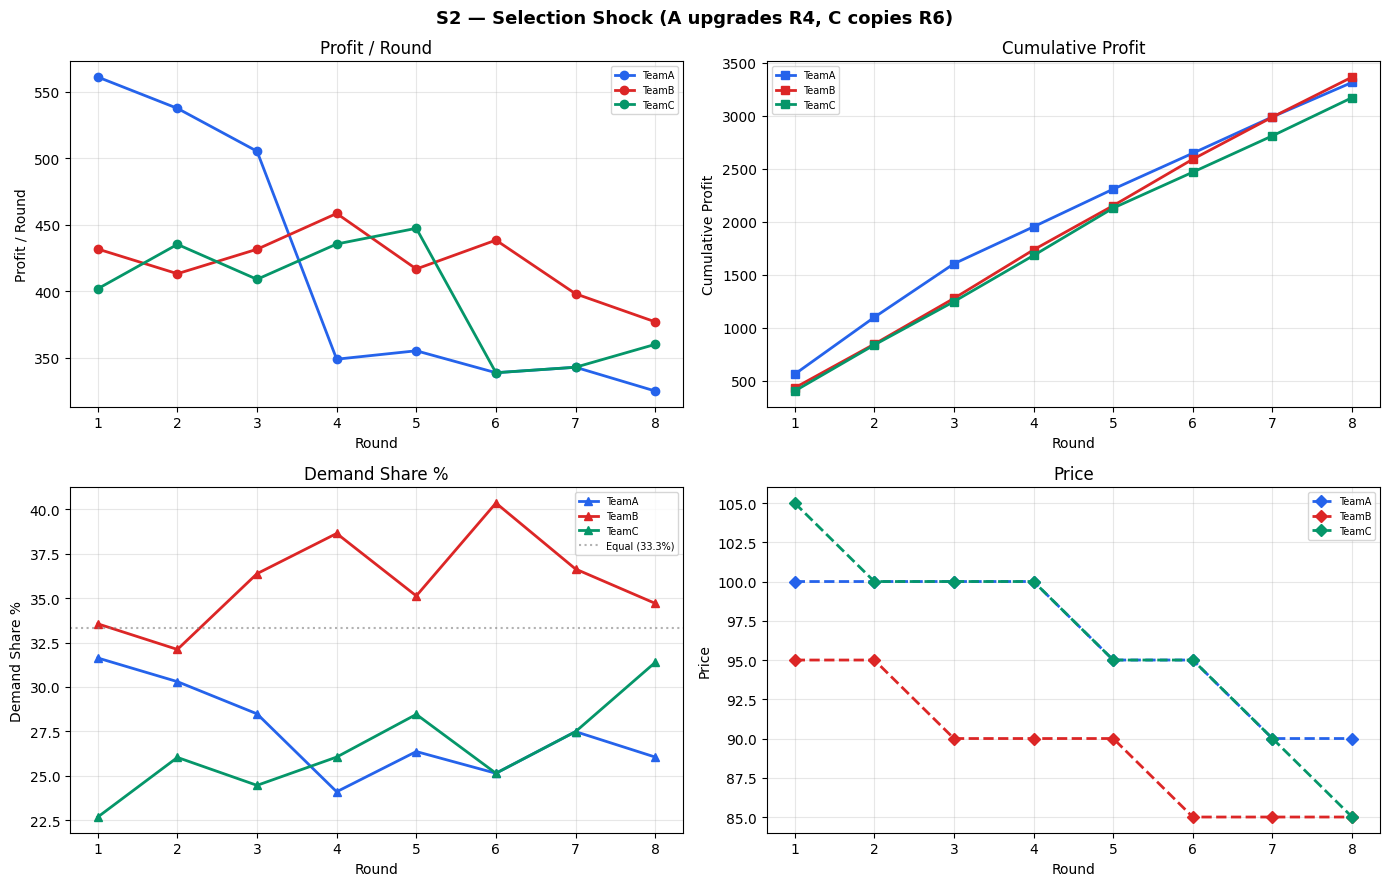

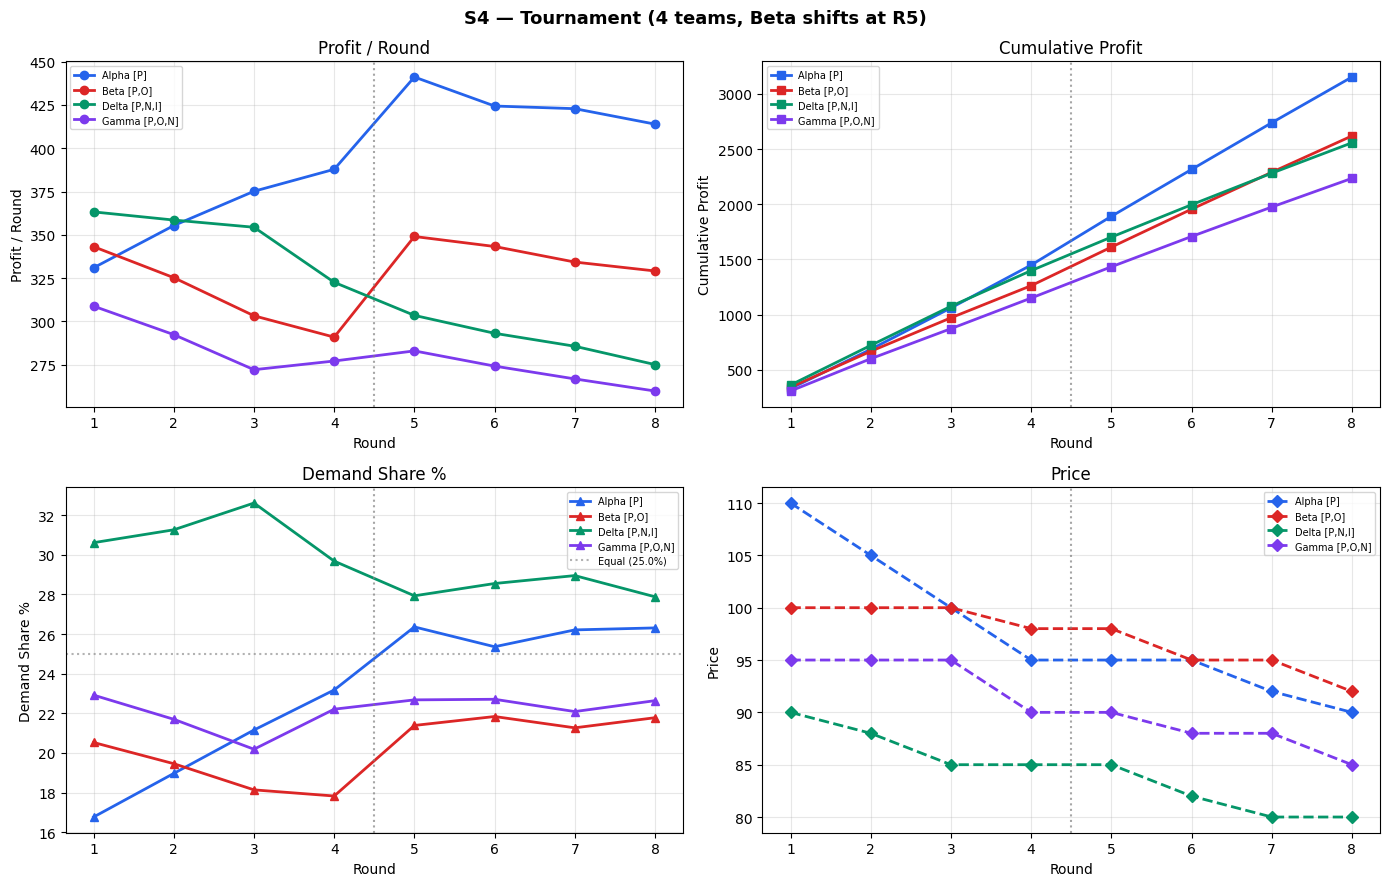

Time-series done.


In [7]:
def team_colors(teams):
    return {t: PALETTE[i % len(PALETTE)] for i,t in enumerate(sorted(teams))}

def plot_ts(df, title, figsize=(14,9)):
    teams = sorted(df['team'].unique()); colors = team_colors(teams)
    fig, axes = plt.subplots(2, 2, figsize=figsize)
    fig.suptitle(title, fontsize=13, fontweight='bold')
    specs_list = [
        ('realized_profit',  'Profit / Round',       'o', '-'),
        ('cum_profit',       'Cumulative Profit',    's', '-'),
        ('demand_share_pct', 'Demand Share %',       '^', '-'),
        ('price',            'Price',                'D', '--'),
    ]
    for ax, (col, ylabel, marker, ls) in zip(axes.flat, specs_list):
        for team in teams:
            td = df[df['team']==team].sort_values('round_no')
            ax.plot(td['round_no'], td[col], marker=marker, label=team,
                    color=colors[team], linewidth=2, linestyle=ls)
        if col == 'demand_share_pct':
            ax.axhline(100/len(teams), color='gray', linestyle=':', alpha=0.6,
                       label=f'Equal ({100/len(teams):.1f}%)')
        ax.set_title(ylabel); ax.set_xlabel('Round'); ax.set_ylabel(ylabel)
        ax.legend(fontsize=7); ax.grid(alpha=0.3)
        ax.xaxis.set_major_locator(plt.MaxNLocator(integer=True))
    plt.tight_layout()
    return fig

fig1 = plot_ts(s1_r, 'S1 — Price War (same set [P], 6 rounds)')
plt.savefig('s1_timeseries.png', dpi=120, bbox_inches='tight'); plt.show()

fig2 = plot_ts(s2_r, 'S2 — Selection Shock (A upgrades R4, C copies R6)')
plt.savefig('s2_timeseries.png', dpi=120, bbox_inches='tight'); plt.show()

fig4 = plot_ts(s4_r, 'S4 — Tournament (4 teams, Beta shifts at R5)')
for ax in fig4.get_axes():
    ax.axvline(4.5, color='gray', linestyle=':', linewidth=1.5, alpha=0.7)
plt.savefig('s4_timeseries.png', dpi=120, bbox_inches='tight'); plt.show()
print('Time-series done.')


### Pie Charts — Demand Share by Round

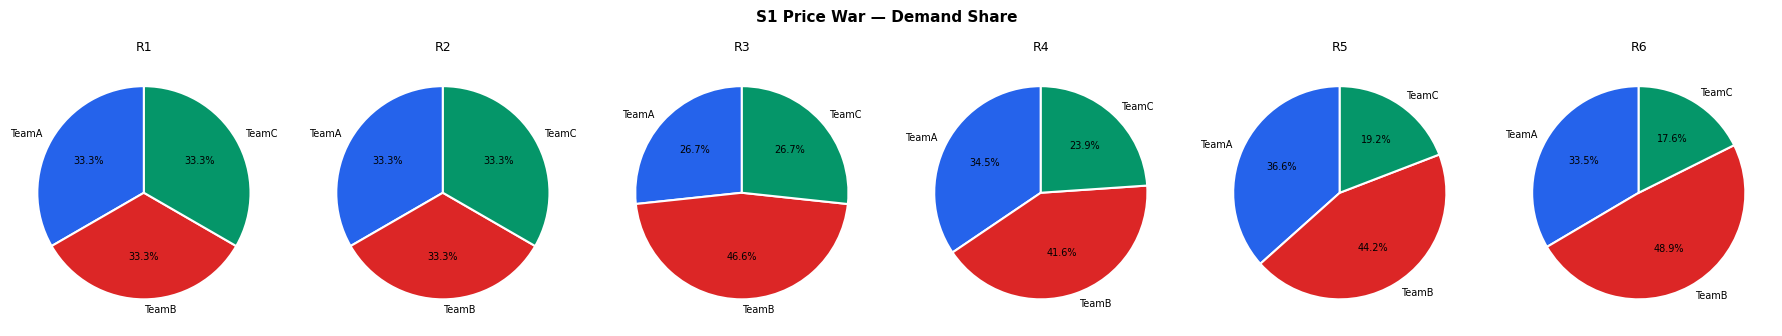

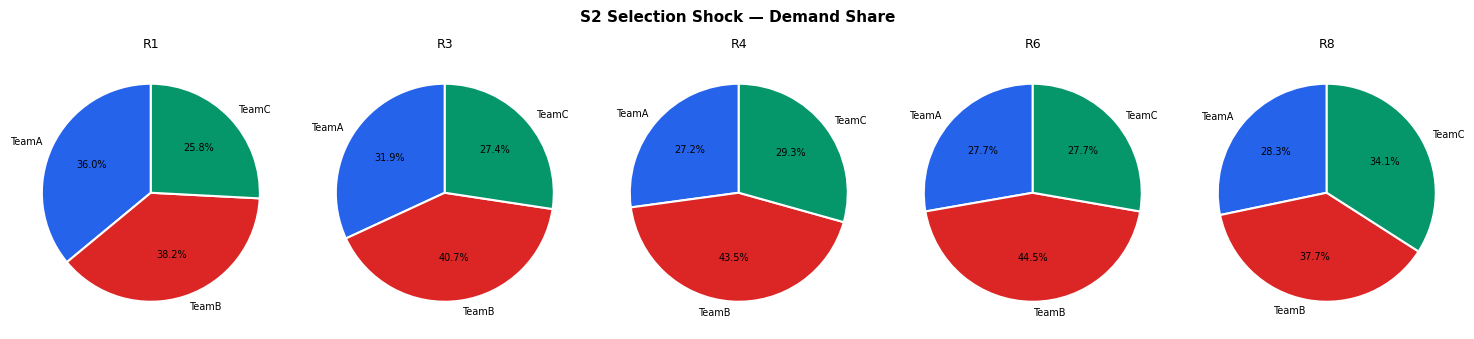

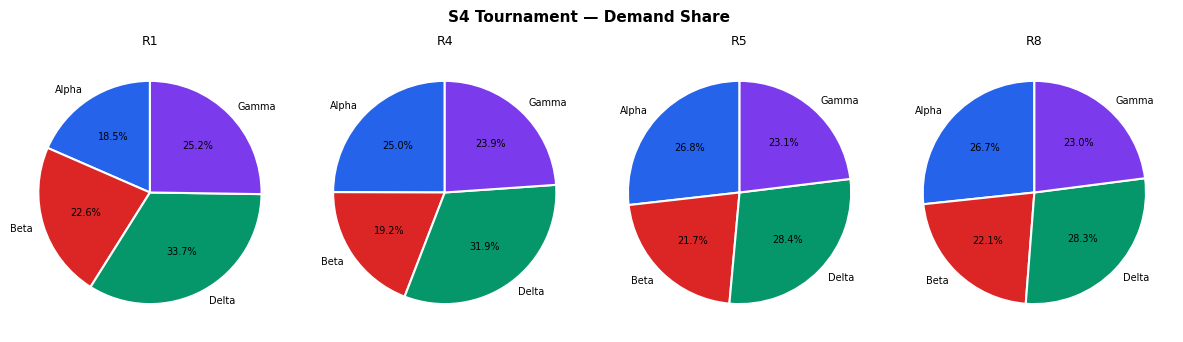

Pies done.


In [8]:
def plot_pies(df, scenario_name, rounds=None):
    if rounds is None: rounds = sorted(df['round_no'].unique())
    n = len(rounds)
    fig, axes = plt.subplots(1, n, figsize=(3*n, 3.5))
    if n == 1: axes = [axes]
    fig.suptitle(f'{scenario_name} — Demand Share', fontsize=11, fontweight='bold')
    teams = sorted(df['team'].unique())
    colors = [PALETTE[i%len(PALETTE)] for i in range(len(teams))]
    wedge = {'edgecolor':'white','linewidth':1.5}
    for ax, rno in zip(axes, rounds):
        rd = df[df['round_no']==rno].sort_values('team')
        shares = rd['demand_share_pct'].values
        lbls = [t.split('[')[0].strip() or t for t in rd['team'].values]
        ax.pie(shares, labels=lbls, colors=colors[:len(shares)], autopct='%1.1f%%',
               startangle=90, wedgeprops=wedge, textprops={'fontsize':7})
        ax.set_title(f'R{rno}', fontsize=9)
    plt.tight_layout()
    return fig

plot_pies(s1_r, 'S1 Price War', [1,2,3,4,5,6])
plt.savefig('s1_pies.png', dpi=110, bbox_inches='tight'); plt.show()

plot_pies(s2_r, 'S2 Selection Shock', [1,3,4,6,8])
plt.savefig('s2_pies.png', dpi=110, bbox_inches='tight'); plt.show()

plot_pies(s4_r, 'S4 Tournament', [1,4,5,8])
plt.savefig('s4_pies.png', dpi=110, bbox_inches='tight'); plt.show()
print('Pies done.')


### Per-Segment Heatmaps (MNL share × segment, one round at a time)

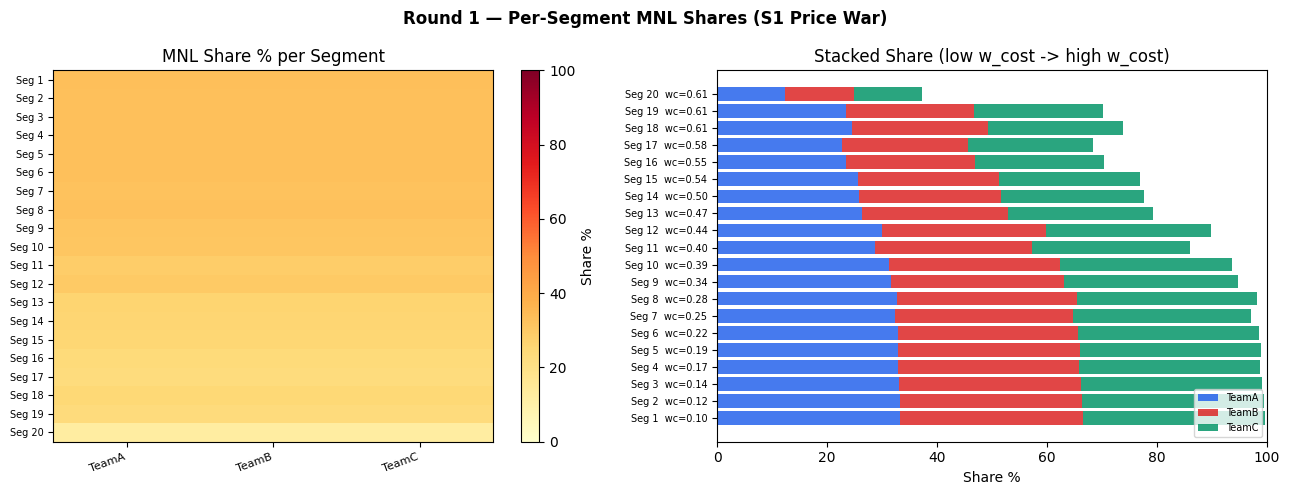

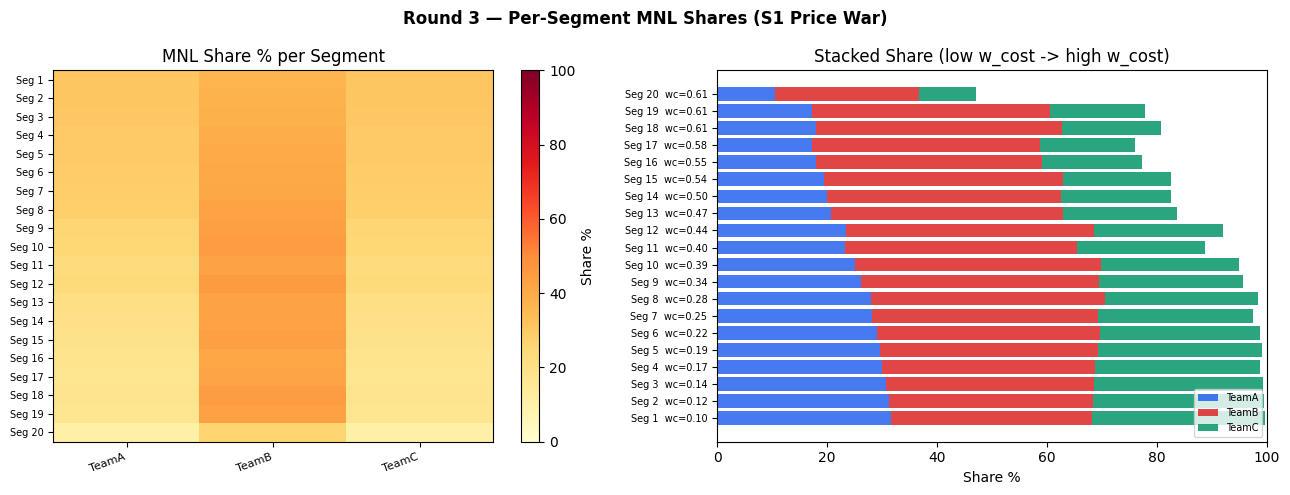

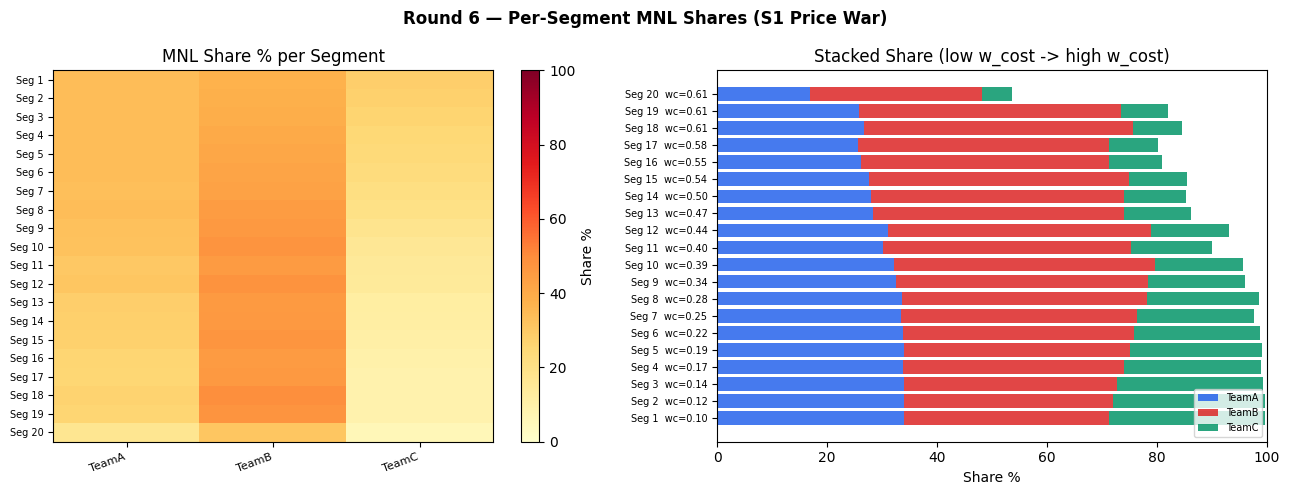

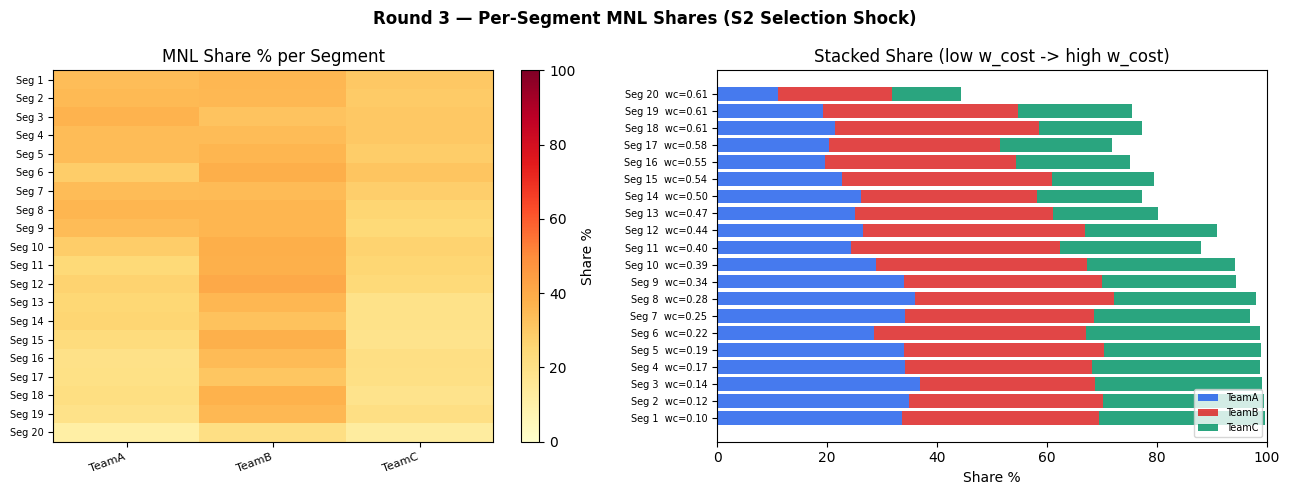

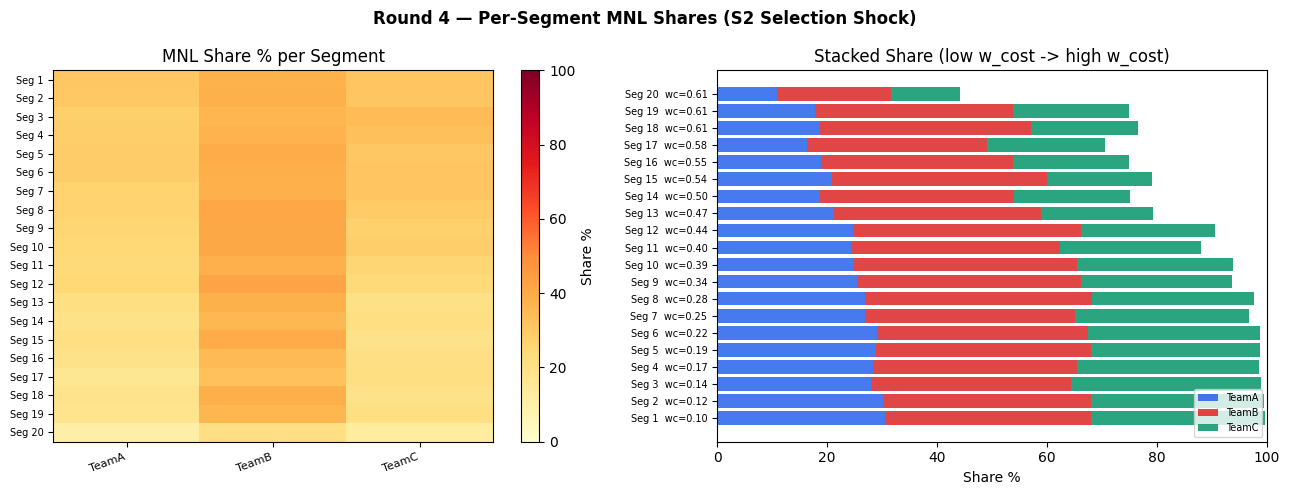

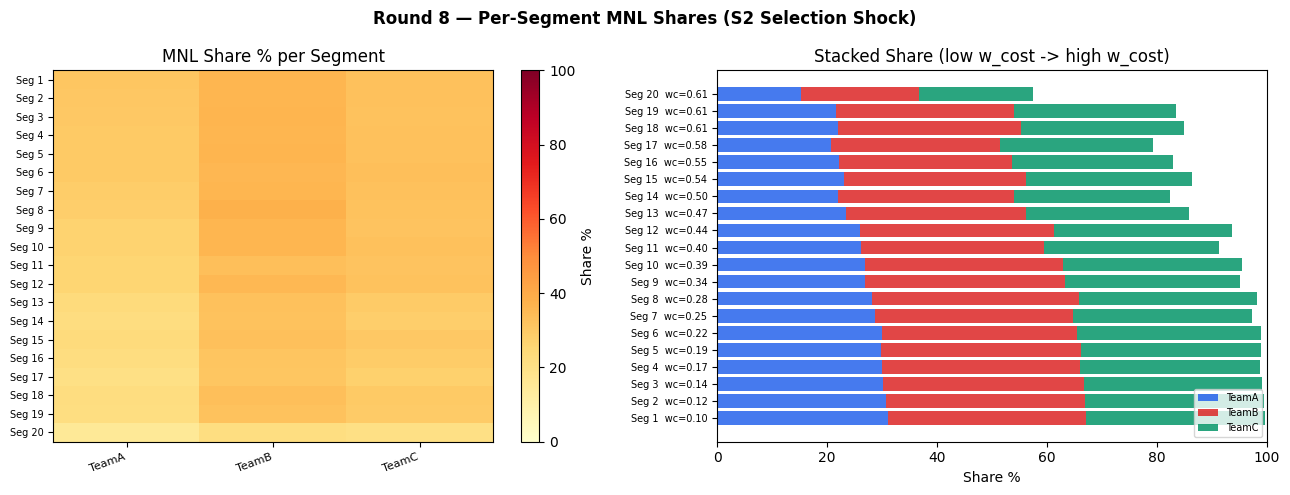

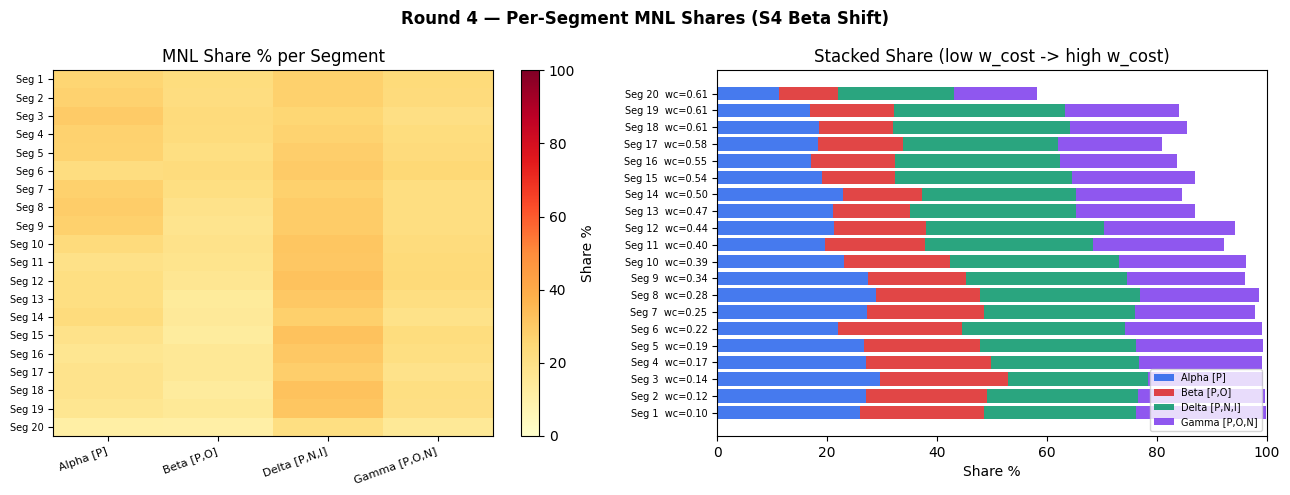

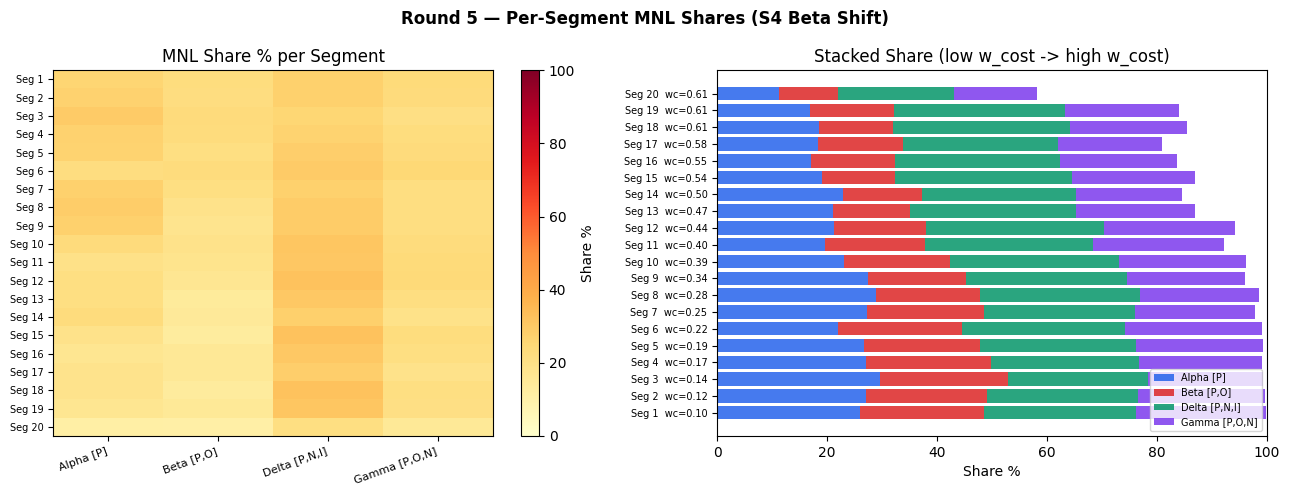

Heatmaps done.


In [9]:
def plot_seg_heatmap(sdf, rnd, title_sfx=''):
    rd = sdf[sdf['round_no']==rnd].copy().sort_values('segment_index')
    if rd.empty: return
    teams = sorted(rd['team'].unique())
    pivot = rd.pivot_table(index='segment_index', columns='team',
                            values='mnl_share_pct', aggfunc='first')[teams]
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
    fig.suptitle(f'Round {rnd} — Per-Segment MNL Shares {title_sfx}',
                 fontsize=12, fontweight='bold')
    # heatmap
    im = ax1.imshow(pivot.values, aspect='auto', cmap='YlOrRd', vmin=0, vmax=100)
    ax1.set_xticks(range(len(teams)))
    ax1.set_xticklabels(teams, rotation=20, ha='right', fontsize=8)
    ax1.set_yticks(range(len(pivot)))
    ax1.set_yticklabels([f'Seg {i}' for i in pivot.index], fontsize=7)
    ax1.set_title('MNL Share % per Segment')
    plt.colorbar(im, ax=ax1, label='Share %')
    # stacked bar
    wcosts = rd.drop_duplicates('segment_index').sort_values('segment_index')['w_cost'].values
    bottom = np.zeros(len(pivot))
    for j, team in enumerate(teams):
        vals = pivot[team].fillna(0).values
        ax2.barh(range(len(pivot)), vals, left=bottom,
                 label=team, color=PALETTE[j%len(PALETTE)], alpha=0.85)
        bottom += vals
    ax2.set_yticks(range(len(pivot)))
    ax2.set_yticklabels([f'Seg {i}  wc={wc:.2f}' for i,wc in zip(pivot.index,wcosts)], fontsize=7)
    ax2.set_xlabel('Share %')
    ax2.set_title('Stacked Share (low w_cost -> high w_cost)')
    ax2.legend(fontsize=7, loc='lower right'); ax2.set_xlim(0,100)
    plt.tight_layout()
    return fig

# S1: before, during, after price war
for rno in [1, 3, 6]:
    plot_seg_heatmap(s1_s, rno, '(S1 Price War)')
    plt.savefig(f's1_seg_r{rno}.png', dpi=100, bbox_inches='tight'); plt.show()

# S2: just before and just after selection upgrade
for rno in [3, 4, 8]:
    plot_seg_heatmap(s2_s, rno, '(S2 Selection Shock)')
    plt.savefig(f's2_seg_r{rno}.png', dpi=100, bbox_inches='tight'); plt.show()

# S4: last Bell round vs first QualPref round
for rno in [4, 5]:
    plot_seg_heatmap(s4_s, rno, '(S4 Beta Shift)')
    plt.savefig(f's4_seg_r{rno}.png', dpi=100, bbox_inches='tight'); plt.show()
print('Heatmaps done.')


### Delta Sweep — Price Sensitivity Chart

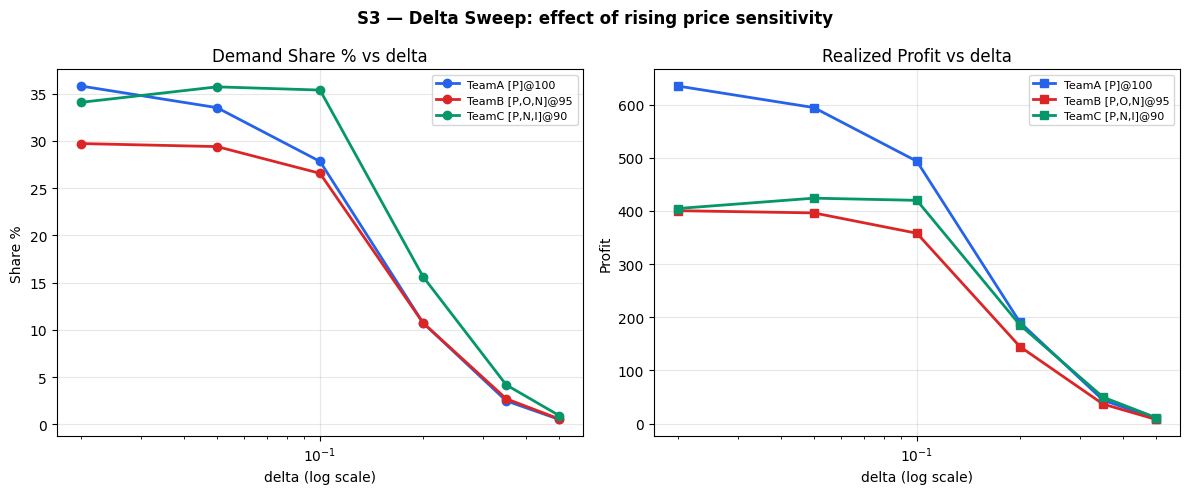

Delta chart done.


In [10]:
fig_d, axes = plt.subplots(1, 2, figsize=(12, 5))
fig_d.suptitle('S3 — Delta Sweep: effect of rising price sensitivity',
               fontsize=12, fontweight='bold')
teams = sorted(s3_r['team'].unique()); colors = team_colors(teams)
for team in teams:
    td = s3_r[s3_r['team']==team].sort_values('delta')
    axes[0].plot(td['delta'], td['demand_share_pct'], marker='o',
                 label=team, color=colors[team], linewidth=2)
    axes[1].plot(td['delta'], td['realized_profit'], marker='s',
                 label=team, color=colors[team], linewidth=2)
for ax, title, ylabel in zip(axes,
    ['Demand Share % vs delta','Realized Profit vs delta'],
    ['Share %','Profit']):
    ax.set_title(title); ax.set_xlabel('delta (log scale)')
    ax.set_ylabel(ylabel); ax.set_xscale('log')
    ax.legend(fontsize=8); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('s3_delta.png', dpi=120, bbox_inches='tight'); plt.show()
print('Delta chart done.')


### Utility Time-Series — All Scenarios

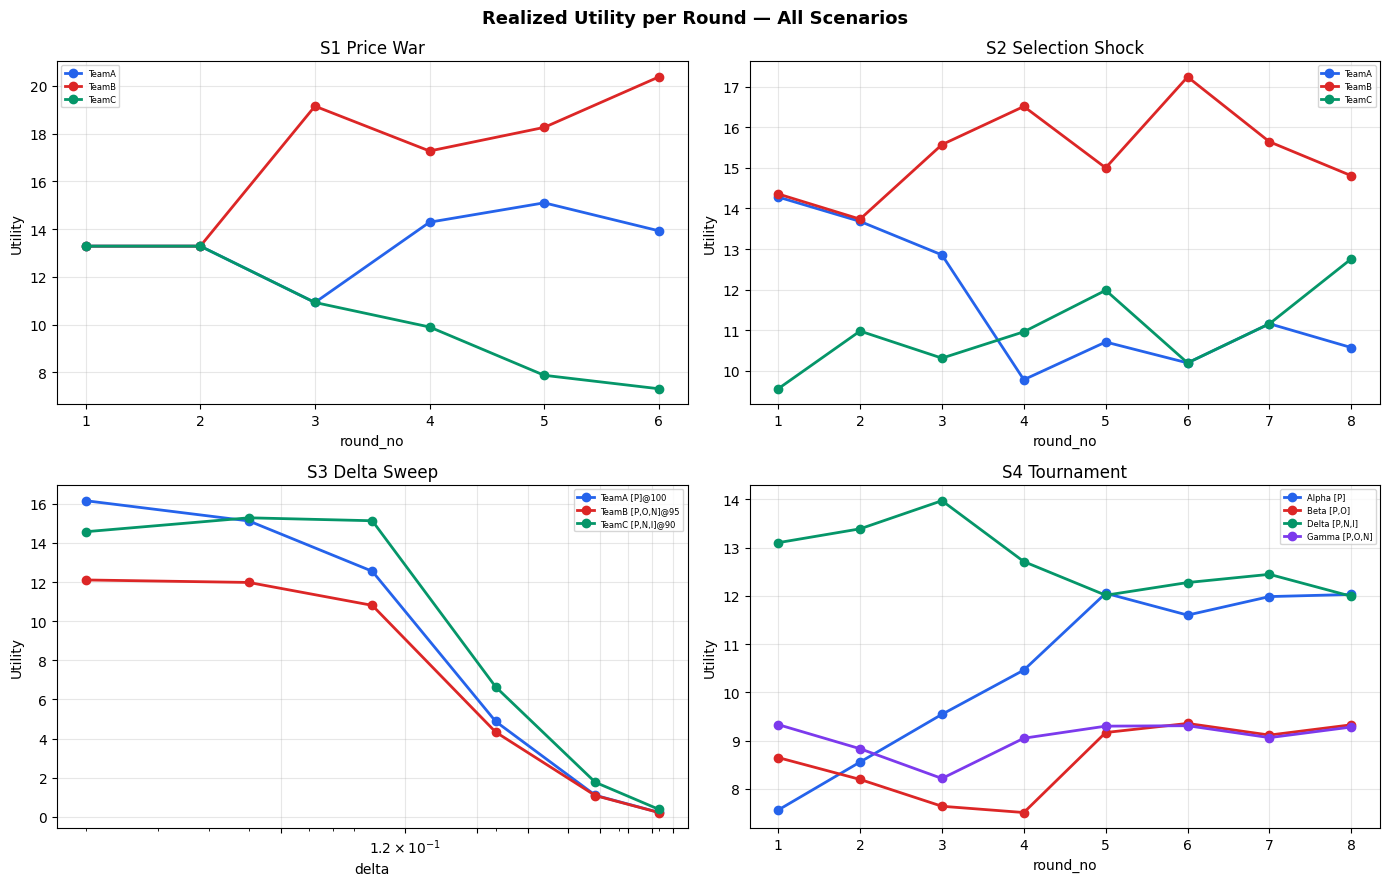

Utility charts done.


In [11]:
fig_u, axes = plt.subplots(2, 2, figsize=(14,9))
fig_u.suptitle('Realized Utility per Round — All Scenarios', fontsize=13, fontweight='bold')
for ax, (df, label, xcol) in zip(axes.flat, [
    (s1_r,'S1 Price War',       'round_no'),
    (s2_r,'S2 Selection Shock', 'round_no'),
    (s3_r,'S3 Delta Sweep',     'delta'),
    (s4_r,'S4 Tournament',      'round_no'),
]):
    teams = sorted(df['team'].unique()); colors = team_colors(teams)
    for team in teams:
        td = df[df['team']==team].sort_values(xcol)
        ax.plot(td[xcol], td['realized_utility'], marker='o',
                label=team, color=colors[team], linewidth=2)
    ax.set_title(label); ax.set_xlabel(xcol); ax.set_ylabel('Utility')
    if xcol == 'delta': ax.set_xscale('log')
    ax.legend(fontsize=6); ax.grid(alpha=0.3)
    ax.xaxis.set_major_locator(plt.MaxNLocator(integer=True))
plt.tight_layout()
plt.savefig('all_utility.png', dpi=120, bbox_inches='tight'); plt.show()
print('Utility charts done.')


## Export to Excel

In [12]:
OUTPUT = Path('round_simulation_results.xlsx')

def profit_pivot(df):
    return df.pivot_table(index='team', columns='round_no',
                          values='realized_profit', aggfunc='first').round(1)
def cum_pivot(df):
    return df.pivot_table(index='team', columns='round_no',
                          values='cum_profit', aggfunc='last').round(1)
def share_pivot(df):
    return df.pivot_table(index='team', columns='round_no',
                          values='demand_share_pct', aggfunc='first').round(2)
def utility_pivot(df):
    return df.pivot_table(index='team', columns='round_no',
                          values='realized_utility', aggfunc='first').round(3)
def seg_avg(sdf):
    return sdf.groupby(['segment_index','team'])['mnl_share_pct'].mean().unstack().round(2)
def seg_rnd(sdf, rno):
    return sdf[sdf['round_no']==rno].pivot_table(
        index='segment_index', columns='team',
        values='mnl_share_pct', aggfunc='first').round(2)

with pd.ExcelWriter(OUTPUT, engine='openpyxl') as w:
    # Raw data
    s1_r.to_excel(w, sheet_name='S1_Rounds',      index=False)
    s1_s.to_excel(w, sheet_name='S1_Segments',    index=False)
    s2_r.to_excel(w, sheet_name='S2_Rounds',      index=False)
    s2_s.to_excel(w, sheet_name='S2_Segments',    index=False)
    s3_r.to_excel(w, sheet_name='S3_Rounds',      index=False)
    s3_s.to_excel(w, sheet_name='S3_Segments',    index=False)
    s4_r.to_excel(w, sheet_name='S4_Rounds',      index=False)
    s4_s.to_excel(w, sheet_name='S4_Segments',    index=False)
    # Pivots
    profit_pivot(s1_r).to_excel(w,  sheet_name='S1_Profit_Pivot')
    cum_pivot(s1_r).to_excel(w,     sheet_name='S1_CumProfit_Pivot')
    share_pivot(s1_r).to_excel(w,   sheet_name='S1_Share_Pivot')
    utility_pivot(s1_r).to_excel(w, sheet_name='S1_Utility_Pivot')
    profit_pivot(s2_r).to_excel(w,  sheet_name='S2_Profit_Pivot')
    cum_pivot(s2_r).to_excel(w,     sheet_name='S2_CumProfit_Pivot')
    share_pivot(s2_r).to_excel(w,   sheet_name='S2_Share_Pivot')
    profit_pivot(s4_r).to_excel(w,  sheet_name='S4_Profit_Pivot')
    cum_pivot(s4_r).to_excel(w,     sheet_name='S4_CumProfit_Pivot')
    share_pivot(s4_r).to_excel(w,   sheet_name='S4_Share_Pivot')
    # Segment breakdowns
    seg_avg(s1_s).to_excel(w,      sheet_name='S1_SegShare_AllRnd_Avg')
    seg_avg(s2_s).to_excel(w,      sheet_name='S2_SegShare_AllRnd_Avg')
    seg_avg(s4_s).to_excel(w,      sheet_name='S4_SegShare_AllRnd_Avg')
    seg_rnd(s1_s,1).to_excel(w,   sheet_name='S1_Seg_R1_Baseline')
    seg_rnd(s1_s,3).to_excel(w,   sheet_name='S1_Seg_R3_PriceCut')
    seg_rnd(s1_s,6).to_excel(w,   sheet_name='S1_Seg_R6_Final')
    seg_rnd(s2_s,3).to_excel(w,   sheet_name='S2_Seg_R3_BeforeUpgrade')
    seg_rnd(s2_s,4).to_excel(w,   sheet_name='S2_Seg_R4_AfterUpgrade')
    seg_rnd(s4_s,4).to_excel(w,   sheet_name='S4_Seg_R4_Bell')
    seg_rnd(s4_s,5).to_excel(w,   sheet_name='S4_Seg_R5_QualPref')

print(f'Saved -> {OUTPUT.resolve()}')
print(f'Total raw rows: {sum(len(d) for d in [s1_r,s1_s,s2_r,s2_s,s3_r,s3_s,s4_r,s4_s])}')


Saved -> C:\Users\LENOVO\Desktop\Asistan\Arya Phone\arya_fullstack_app\server\tests\round_simulation_results.xlsx
Total raw rows: 1932


## Summary

In [13]:
print('='*65)
print('SIMULATION SUMMARY')
print('='*65)
for label, df in [('S1 Price War',s1_r),('S2 Selection Shock',s2_r),
                   ('S3 Delta Sweep',s3_r),('S4 Tournament',s4_r)]:
    final = df.groupby('team')['realized_profit'].sum().sort_values(ascending=False)
    print()
    print(label + ' - Total Profit Ranking:')
    for team, profit in final.items():
        avg_share = df[df['team']==team]['demand_share_pct'].mean()
        print(f'  {team:<38} profit={profit:7.0f}  avg_share={avg_share:.1f}%')
print()
print('S3 - Price leader ([P,N,I]@90) vs delta:')
for _, row in s3_r[s3_r['team'].str.contains('90')].sort_values('round_no').iterrows():
    d = row['delta']; sh = row['demand_share_pct']; pr = row['realized_profit']
    print(f'  delta={d:.2f}  share={sh:.1f}%  profit={pr:.0f}')


SIMULATION SUMMARY

S1 Price War - Total Profit Ranking:
  TeamB                                  profit=   3448  avg_share=37.5%
  TeamA                                  profit=   2986  avg_share=29.9%
  TeamC                                  profit=   2518  avg_share=23.2%

S2 Selection Shock - Total Profit Ranking:
  TeamB                                  profit=   3366  avg_share=35.9%
  TeamA                                  profit=   3315  avg_share=27.4%
  TeamC                                  profit=   3171  avg_share=26.5%

S3 Delta Sweep - Total Profit Ranking:
  TeamA [P]@100                          profit=   1966  avg_share=18.5%
  TeamC [P,N,I]@90                       profit=   1494  avg_share=21.0%
  TeamB [P,O,N]@95                       profit=   1344  avg_share=16.6%

S4 Tournament - Total Profit Ranking:
  Alpha [P]                              profit=   3152  avg_share=23.0%
  Beta [P,O]                             profit=   2619  avg_share=20.3%
  Delta [P,N,I]  